# Analyse univariée et bivariée des données
## TP fil rouge : Parcoursup 2025

**Données** : formations proposées sur Parcoursup en 2025 (ministère de l'Enseignement supérieur, data.enseignementsup-recherche.gouv.fr).

**Organisation** : en binôme, un dépôt GitHub par binôme. Un commit à la fin de chaque partie.

Pour chaque question : du code, **et** une interprétation rédigée. Un chiffre sans phrase ne vaut rien.

---

### 🎯 La question de l'enquête

> **Qu'est-ce qui rend une formation sélective sur Parcoursup ?**

La sélectivité se mesure avec `taux_acces_ens` : la part des candidats qui ont reçu une proposition d'admission. Plus il est **bas**, plus la formation est **sélective**.

Chaque partie du TP fait avancer l'enquête. À la fin de chaque jour, vous rédigez une synthèse : *ce qu'on sait à ce stade sur la sélectivité*. La conclusion finale fait partie du TP noté.

# J1 matin — Comprendre les fondements de l'univarié

## Mise en place

Créez votre dépôt GitHub, clonez-le, placez `parcoursup.csv` dans un dossier `data/`.

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Chargez le fichier (séparateur : `;`). Combien de lignes et de colonnes ?

In [7]:
df = pd.read_csv("data/parcoursup.csv", sep=";")
df.info()
# df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 14252 entries, 0 to 14251
Columns: 118 entries, session to composante_id_paysage
dtypes: float64(40), int64(55), str(23)
memory usage: 12.8 MB


C:\Users\mathi\AppData\Local\Temp\ipykernel_6152\2668257594.py:1: DtypeWarning: Columns (0: detail_forma2) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("data/parcoursup.csv", sep=";")


## 1. Typologie des variables

🎯 *Enquête* : avant de chercher ce qui explique la sélectivité, il faut savoir quelles variables on a et comment les traiter.

Classez au moins ces colonnes : `fili`, `contrat_etab`, `select_form`, `cod_uai`, `capa_fin`, `voe_tot`, `taux_acces_ens`, `pct_bours`. Pour chacune : codage (ce que voit pandas), nature statistique, traitement retenu et justification.

| Variable | Codage | Nature statistique | Traitement retenu | Justification |
|---|---|---|---|---|
| | | | | |

In [8]:
Target = ["fili", "contrat_etab", "select_form", "cod_uai", "capa_fin", "voe_tot", "taux_acces_ens", "pct_bours"]
df[Target].dtypes

fili                  str
contrat_etab          str
select_form           str
cod_uai               str
capa_fin            int64
voe_tot             int64
taux_acces_ens    float64
pct_bours         float64
dtype: object

> 💾 **Commit** : « Typologie des variables »

## 2. Tendance centrale

🎯 *Enquête* : à quoi ressemble une formation « typique » ? Est-elle sélective ? On regarde d'abord la sélectivité, puis deux causes possibles : la demande (`voe_tot`) et la taille (`capa_fin`).

**2.1** Moyenne et médiane de `taux_acces_ens`. Que remarquez-vous ?

In [ ]:
print("Moyenne : ", df["taux_acces_ens"].mean())
print("Mediane : ", df["taux_acces_ens"].median())

Moyenne :  56.14736250614596
Mediane :  54.0


**Interprétation** : Sur toutes les demandes, les formations acceptent la moitié des demandes.

**2.2** Moyenne et médiane de `voe_tot`. Une formation très demandée sera-t-elle forcément sélective ? Gardez la question en tête.

In [ ]:
print("Moyenne : ", df["voe_tot"].mean())
print("Mediane : ", df["voe_tot"].median())

Moyenne :  947.4028206567499
Mediane :  385.0


**Interprétation** : La majorité des formations reçoivent beaucoup de demandes.

**2.3** Quelle formation a la plus grande capacité (`capa_fin`) ? Que deviennent la moyenne et la médiane sans elle ?

In [ ]:
df.loc[df["capa_fin"].idxmax(), ["lib_for_voe_ins", "capa_fin", "voe_tot", "acc_tot"]]

lib_for_voe_ins    BTS - Services - Diététique et nutrition - Ent...
capa_fin                                                        3400
voe_tot                                                         1614
acc_tot                                                          512
Name: 10282, dtype: object

**Interprétation** : La formation avec la plus grande capacité est entiérement en distanciel donc il y a beaucoup de place mais moins d'acceptation.

**2.4** Mode de `fili` et de `contrat_etab`.

In [ ]:
print(df["fili"].mode()[0])
print(df["contrat_etab"].mode()[0])

BTS
Public


**Interprétation** : Si il y a autant de demandes c'est parce que ce sont des formations courte et gratuite

> 💾 **Commit** : « Tendance centrale »

## 3. Dispersion

🎯 *Enquête* : les formations sont-elles toutes à peu près aussi sélectives, ou y a-t-il de grands écarts à expliquer ?

On étudie la dispersion de `voe_tot` de bout en bout, puis on la compare à `taux_acces_ens`.

**3.1** Étendue de `voe_tot` (minimum, maximum, étendue).

In [ ]:
Min = df["voe_tot"].min()
Max = df["voe_tot"].max()
Range = Max - Min

print("Min voeux: ", Min)
print("max voeux: ", Max)
print("Etendue voeux: ", Range)

Min voeux:  1
max voeux:  19404
Etendue voeux:  19403


**Interprétation** : En comparant les résultat avec la moyenne et la médianne, on se rend compte de l'inégalité entre les écoles (Pour approfondir, regarder les formations et la localisation) Avec 2 données, ce n'est pas suffisant pour émettre des conclusion (néanmoins on peux dire ce n'est pas constant, la queue est à droite)

**3.2** Variance pas à pas sur les **10 premières formations** : écarts à la moyenne, écarts au carré, somme des écarts. Calculez la variance en divisant par n, puis par n − 1. Vérifiez avec numpy et pandas.

In [ ]:
df_test = df.sample(10, random_state=67)

Moy10 = df_test["voe_tot"].mean()
Ecart10 = df_test["voe_tot"] - Moy10
Ecart10Carre = Ecart10 ** 2 
SumEcart10 = Ecart10Carre.sum()

Var_n = SumEcart10 / 10
Var_n1 = SumEcart10 / 9

VerifNumpy = np.var(df_test["voe_tot"])
VerifPandas = df_test["voe_tot"].var()

print("Moyenne: ", Moy10)
print("Ecarts au carré: ", Ecart10Carre)
print("Somme des ecarts: ", SumEcart10)
print(" ")
print("Var Numpy calculé: ", Var_n)
print("Var Numpy: ", VerifNumpy)
print(" ")
print("Var Pandas calculé: ", Var_n1)
print("Var Pandas: ", VerifPandas)

Moyenne:  1321.3
Ecarts au carré:  12463     1486692.49
12116     1268551.69
10030      998600.49
9471        75790.09
421       1314003.69
1212        94433.29
11778     1693381.69
13251    52369826.89
3284       288691.29
6570       105170.49
Name: voe_tot, dtype: float64
Somme des ecarts:  59695142.099999994
 
Var Numpy calculé:  5969514.209999999
Var Numpy:  5969514.209999999
 
Var Pandas calculé:  6632793.566666666
Var Pandas:  6632793.566666666


**Interprétation** : Notre tirage possède surement un outlier (.head(10) on remarque un < 8000) le numpy et pandas sont différents à cause de cette valeur

**3.3** Calculez tous les indicateurs de dispersion de `voe_tot` : variance, écart-type, écart absolu moyen, Q1, Q3, IQR, coefficient de variation. Comparez l'écart-type, l'écart absolu moyen et l'IQR.

In [ ]:
Variance = df["voe_tot"].var()
Ecart = df["voe_tot"].std()
EcartAbsolu = (df["voe_tot"] - df["voe_tot"].mean()).abs().std()

q1 = df["voe_tot"].quantile(0.25)
q3 = df["voe_tot"].quantile(0.75)
iqr = q3 - q1

coef_variation = (Ecart / df["voe_tot"].mean()) * 100

print("Variance: ", Variance)
print("Ecart-Type: ", Ecart)
print("Ecart-Absolu-Moyen: ", EcartAbsolu)
print("Q1: ", q1)
print("Q3: ", q3)
print("iqr: ", iqr)
print("Coefficient de variation: ", coef_variation)

Variance:  2509634.0870399703
Ecart-Type:  1584.182466460215
Ecart-Absolu-Moyen:  1282.5231808446124
Q1:  160.0
Q3:  1016.0
iqr:  856.0
Coefficient de variation:  167.21318872177756


**Interprétation** : On remarque qu'il y a une grande dispersion en dessous et au dessus de la moyenne, donc beaucoup d'inégalité de voeux entre les écoles. 
Mais l'écart interquartile se rapproche de de la moyenne en prenant en compte les outlier. 
En prenant en compte qu'il y a dans les 2 millions de voeux on a bien une moyenne de 800 voeux par formation

**3.4** Comparez la dispersion de `voe_tot` et de `taux_acces_ens` (écart-type, IQR, coefficient de variation). Laquelle est la plus dispersée ? Qu'est-ce que ça dit des écarts de sélectivité entre formations ?

In [ ]:
VarianceAcces = df["taux_acces_ens"].var()
EcartAcces = df["taux_acces_ens"].std()
EcartAbsoluAcces = (df["taux_acces_ens"] - df["taux_acces_ens"].mean()).abs().std()

q1Acces = df["taux_acces_ens"].quantile(0.25)
q3Acces = df["taux_acces_ens"].quantile(0.75)
iqrAcces = q3Acces - q1Acces

coef_variationAcces = (EcartAcces / df["taux_acces_ens"].mean()) * 100

print("Variance: ", VarianceAcces)
print("Ecart-Type: ", EcartAcces)
print("Ecart-Absolu-Moyen: ", EcartAbsoluAcces)
print("Q1: ", q1Acces)
print("Q3: ", q3Acces)
print("iqr: ", iqrAcces)
print("Coefficient de variation: ", coef_variationAcces)

Variance:  817.4264423617664
Ecart-Type:  28.590670547606372
Ecart-Absolu-Moyen:  14.702380035891645
Q1:  33.0
Q3:  81.0
iqr:  48.0
Coefficient de variation:  50.92077218137682


**Interprétation** : il y a plus de dispersion du côté des voeux et c'est normal car il y plus de demande en formation que de places donc de possibilité d'acceptation.
Beaucoup de formations sont moins séléctive donc il y a plus de voeux envoyé que des étudiants qui sont acceptés

> 💾 **Commit** : « Dispersion »

## 4. Graphiques

🎯 *Enquête* : voir la sélectivité, et trouver un premier indice de ce qui la fait varier.

**4.1** Histogramme de `taux_acces_ens`. À quelle forme vous attendiez-vous ? Qu'obtenez-vous ?

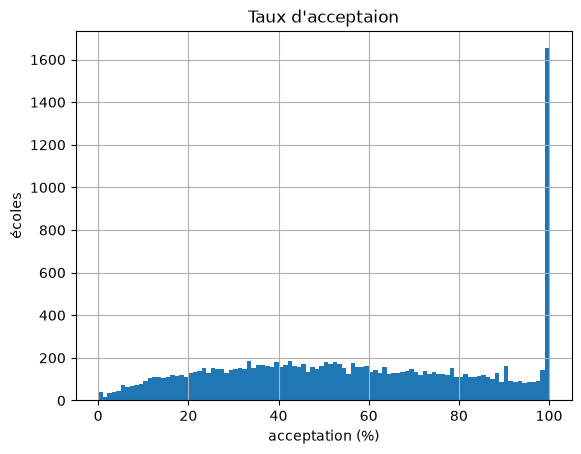

In [17]:
df['taux_acces_ens'].hist(bins=100)
plt.title("Taux d'acceptaion")
plt.xlabel('acceptation (%)')
plt.ylabel('écoles')

plt.show()

**Interprétation** : 
Par les calculs précédent de Q1 et Q3, on pouvait s'attendre à ce résultat sauf la pic à 100%

**4.2** Diagramme en barres de `fili`, trié par effectif.

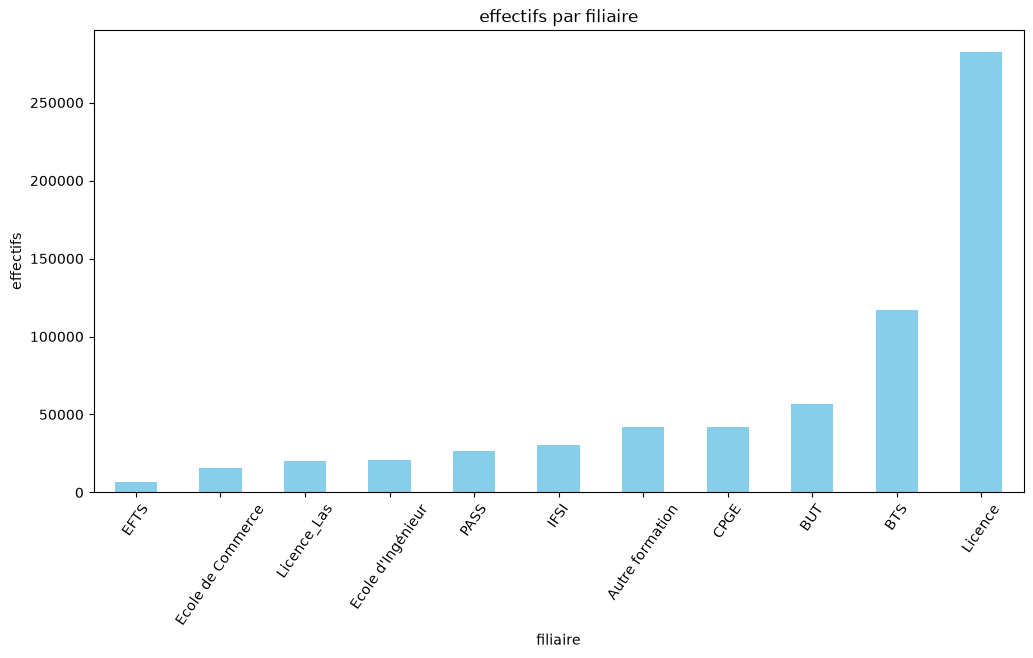

In [18]:
effectifs_filiaire = df.groupby("fili")["acc_tot"].sum().sort_values()

plt.figure(figsize=(12,6))

effectifs_filiaire.plot.bar(color='skyblue', legend=False)

plt.title('effectifs par filiaire')
plt.xlabel('filiaire')
plt.xticks(rotation=55)
plt.ylabel('effectifs')
plt.show()

**4.2 bis** Camembert de `contrat_etab`, puis camembert de `fili`. Lequel est lisible ? Pourquoi ?

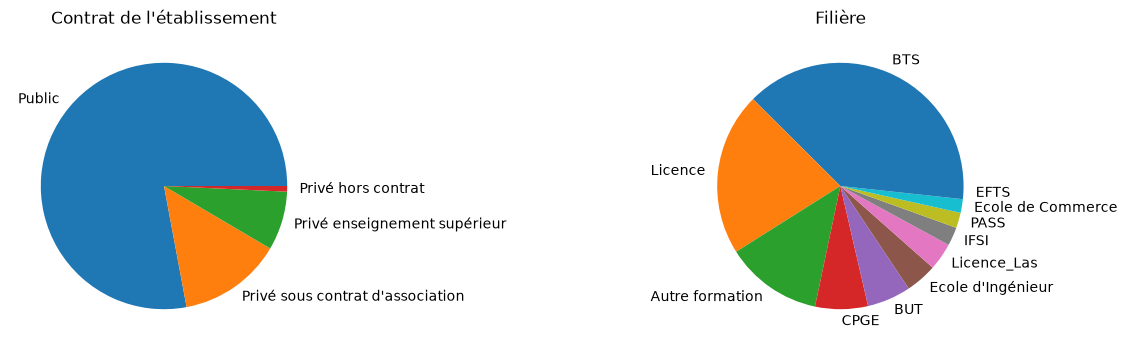

In [ ]:
plt.figure(figsize=(16, 4))

plt.subplot(1, 2, 1)
contrat = df["contrat_etab"].value_counts()
plt.pie(contrat, labels=contrat.index)
plt.title("Contrat de l'établissement")

plt.subplot(1, 2, 2)
fili = df["fili"].value_counts()
plt.pie(fili, labels=fili.index)
plt.title("Filière")

plt.show()

**Interprétation** : Contrat de l'établisement est plus visible car il à moins de choix donc plus de lisibilité des contrats d'établisement

**4.3** Boxplot de `voe_tot`. Est-il lisible ? Que faudrait-il faire ?

C:\Users\mathi\AppData\Local\Temp\ipykernel_6152\3336721806.py:4: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df["voe_tot"], vert=False)
C:\Users\mathi\AppData\Local\Temp\ipykernel_6152\3336721806.py:9: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(np.log1p(df["voe_tot"]), vert=False)


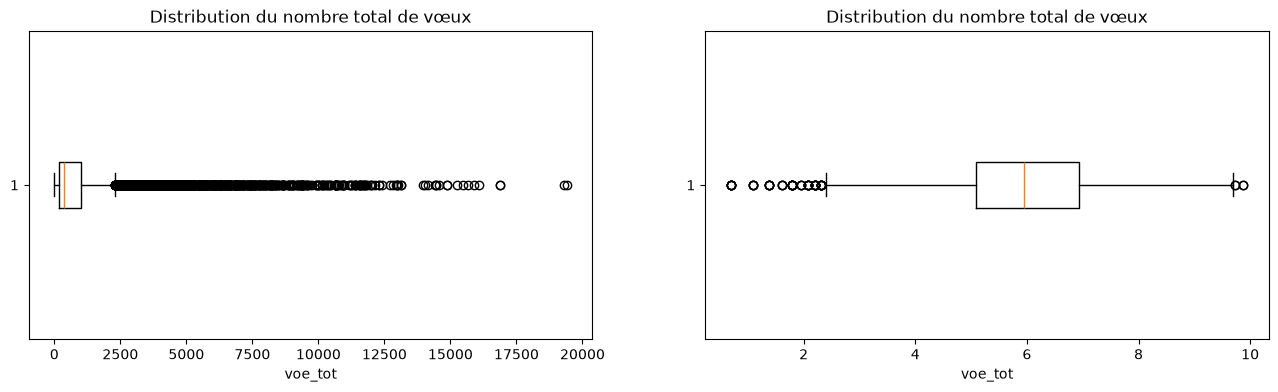

In [ ]:
plt.figure(figsize=(16, 4))

plt.subplot(1, 2, 1)
plt.boxplot(df["voe_tot"], vert=False)
plt.title("Distribution du nombre total de vœux")
plt.xlabel("voe_tot")

plt.subplot(1, 2, 2)
plt.boxplot(np.log1p(df["voe_tot"]), vert=False)
plt.title("Distribution du nombre total de vœux")
plt.xlabel("voe_tot")

plt.show()

**Interprétation** : le Logarithme permet de mieux visualiser notre boite moustache 

**4.4** Boxplots de `taux_acces_ens` selon `select_form`. Premier indice : le label « sélective » correspond-il vraiment à un taux d'accès plus faible ?

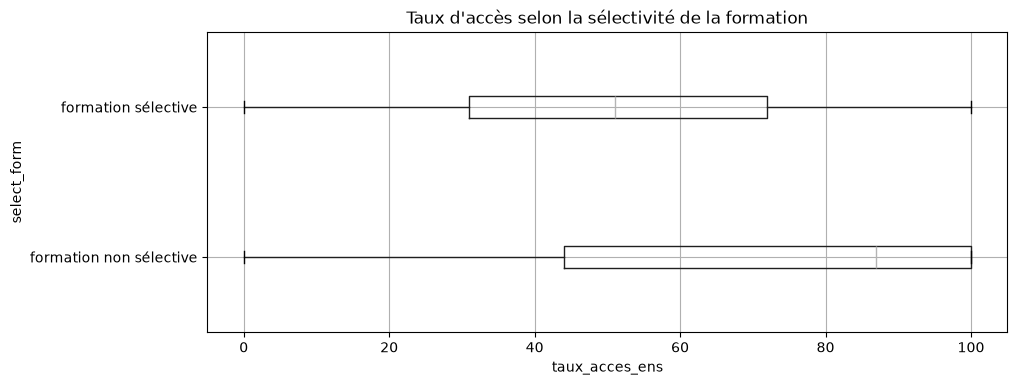

In [ ]:
df.boxplot(column="taux_acces_ens", by="select_form", vert=False, figsize=(10, 4))
plt.title("Taux d'accès selon la sélectivité de la formation")
plt.suptitle(None)
plt.xlabel("taux_acces_ens")

plt.show()

**Interprétation** : Les formations non sélectives ont un taux d'accès médian bien plus élevé

> 💾 **Commit** : « Graphiques », puis **push**.

# J1 après-midi — Approfondir les distributions

In [22]:
from scipy import stats

## 5. Asymétrie et aplatissement

🎯 *Enquête* : la forme des variables décidera des outils à utiliser au J2 pour les relier à la sélectivité.

**5.1** Calculez la skewness et la kurtosis de `voe_tot`, `taux_acces_ens`, `capa_fin` et `pct_bours`. Classez-les de la plus symétrique à la plus asymétrique. Lesquelles faudra-t-il transformer avant de les relier à la sélectivité ?

In [ ]:
var = ["voe_tot", "taux_acces_ens", "capa_fin", "pct_bours"]

objectif = pd.DataFrame({
    "skewness": df[var].skew(),
    "kurtosis": df[var].kurt()
})

objectif

,skewness,kurtosis
voe_tot,4.078029,22.692827
taux_acces_ens,0.026669,-1.136756
capa_fin,12.699780,282.099344
pct_bours,1.127791,1.918332


**Interprétation** : Classement: taux_acces_ens  < pct_bours  < voe_tot  < capa_fin
capa_fin doit etre transformer pour etre plus lisible comme vu avec les boites moustache

> 💾 **Commit** : « Asymétrie »

## 6. La loi normale

🎯 *Enquête* : peut-on utiliser sur la sélectivité les outils qui supposent une loi normale ?

**6.1** Vérifiez la règle 68-95-99,7 sur `taux_acces_ens`. La variable suit-elle une loi normale ? Quelle conséquence pour la suite de l'enquête ?

In [27]:
df['z_score'] = (df['taux_acces_ens'] - df['taux_acces_ens'].mean()) / df['taux_acces_ens'].std()

seuil1 = (df['z_score'].abs() <= 1).mean() * 100
seuil2 = (df['z_score'].abs() <= 2).mean() * 100
seuil3 = (df['z_score'].abs() <= 3).mean() * 100

print(f"Pourcentage entre -1 et +1 Z-score : {seuil1:.2f}% (Théorie : ~68%)")
print(f"Pourcentage entre -2 et +2 Z-score : {seuil2:.2f}% (Théorie : ~95%)")
print(f"Pourcentage entre -3 et +3 Z-score : {seuil3:.2f}% (Théorie : ~99.7%)")

Pourcentage entre -1 et +1 Z-score : 58.58% (Théorie : ~68%)
Pourcentage entre -2 et +2 Z-score : 99.89% (Théorie : ~95%)
Pourcentage entre -3 et +3 Z-score : 99.89% (Théorie : ~99.7%)


**Interprétation** : La variable ne suit pas une loi normale et devons donc découvrir pourquoi.

> 💾 **Commit** : « Loi normale »

## 7. Les distributions réelles

🎯 *Enquête* : la demande (`voe_tot`) est une cause possible de sélectivité. Quelle échelle faudra-t-il utiliser pour la comparer au taux d'accès ?

**7.1** Tracez l'histogramme de `voe_tot`, puis celui de `log(voe_tot)`. Quelle loi reconnaissez-vous ? Quelle échelle utiliserez-vous au J2 pour relier la demande à la sélectivité ?

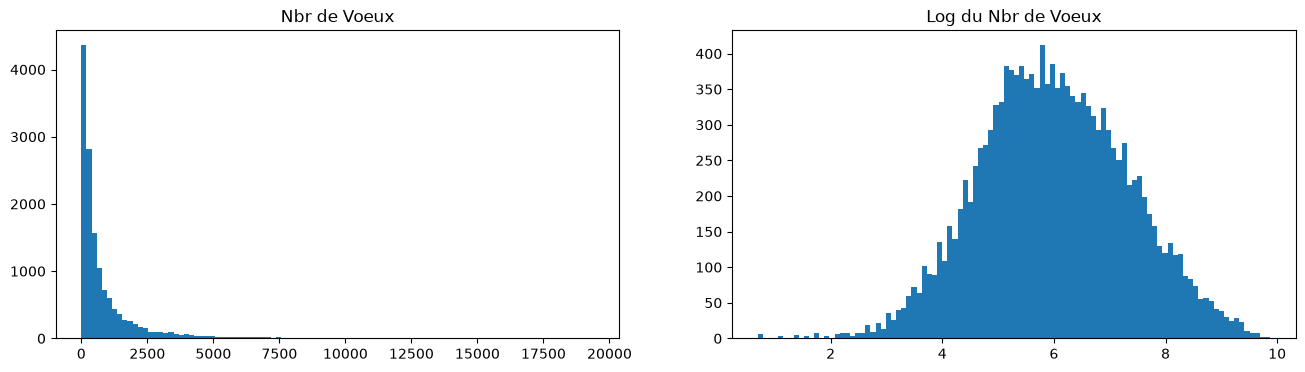

In [ ]:
plt.figure(figsize=(16, 4))

plt.subplot(1, 2, 1)
plt.hist(df["voe_tot"], bins=100)
plt.title("Nbr de Voeux")

plt.subplot(1, 2, 2)
plt.hist(np.log1p(df["voe_tot"]), bins=100)
plt.title("Log du Nbr de Voeux")

plt.show()

**Interprétation** : On peut considérer que "voe_tot" suit la loi log-normal
Pour la suite on utilisera le logaritme pour le relier à la sélectivité

**7.2** Quelle part des vœux concentrent les 10 % et les 20 % de formations les plus demandées ? Est-ce une distribution de type Pareto ?

In [244]:
voeux = df["voe_tot"].sort_values(ascending=False)
total = voeux.sum()
n = len(voeux)

part_10 = voeux.iloc[:int(n * 0.10)].sum() / total
part_20 = voeux.iloc[:int(n * 0.20)].sum() / total

print(f"Top 10 % des formations : {part_10:.1%} des vœux")
print(f"Top 20 % des formations : {part_20:.1%} des vœux")

Top 10 % des formations : 49.8% des vœux
Top 20 % des formations : 68.0% des vœux


**Interprétation** : La demande est très inégalement répartie, on n'est pas assez proche d'une Loi de Pareto (80/20)

> 💾 **Commit** : « Distributions »

## 8. Outliers

🎯 *Enquête* : les formations hors norme risquent de fausser les liens avec la sélectivité. Faut-il les garder ?

**8.1** Détectez les outliers de `capa_fin` avec la méthode IQR, puis avec le Z-score (|z| > 3). Comparez les nombres obtenus et expliquez l'écart.

In [256]:
capa = df["capa_fin"]

# Méthode IQR
q1, q3 = capa.quantile([0.25, 0.75])
iqr = q3 - q1
borne_inf = q1 - 1.5 * iqr
borne_sup = q3 + 1.5 * iqr
outliers_iqr = capa[(capa < borne_inf) | (capa > borne_sup)]

# Méthode Z-score
z = (capa - capa.mean()) / capa.std()
outliers_z = capa[z.abs() > 3]

print(f"IQR : bornes [{borne_inf:.1f} ; {borne_sup:.1f}] -> {len(outliers_iqr)} outliers ({len(outliers_iqr)/len(capa):.1%})")
print(f"Z-score : seuil |z| > 3 -> {len(outliers_z)} outliers ({len(outliers_z)/len(capa):.1%})")

IQR : bornes [-30.0 ; 98.0] -> 1689 outliers (11.9%)
Z-score : seuil |z| > 3 -> 183 outliers (1.3%)


**Interprétation** : "capa_fin" à une grande queue à droite (vu avec les boites moustache) on à donc énormément d'outliers (1689)
Le Z-score lui prend en compte la moyenne et donc à moins d'outlier (183)

**8.2** Affichez les 10 plus grandes capacités. S'agit-il d'erreurs ou de valeurs réelles ? Que faites-vous ? Les garderez-vous pour étudier la sélectivité ?

In [271]:
df.sort_values("capa_fin", ascending=False).head(10)[["lib_for_voe_ins", "capa_fin", "voe_tot", "acc_tot"]]

,lib_for_voe_ins,capa_fin,voe_tot,acc_tot
10282,BTS - Services - Diététique et nutrition - Ent...,3400,1614,512
9035,BTS - Services - Communication - Entièrement e...,3200,1189,281
8393,BTS - Services - Management Commercial Opérati...,2400,1224,194
8389,BTS - Services - Tourisme - Entièrement en dis...,2400,1022,207
7184,BTS - Services - Commerce International - Enti...,2400,1822,369
7185,BTS - Services - Négociation et digitalisation...,2000,1089,194
9033,BTS - Services - Services et prestations des s...,2000,607,127
5888,BTS - Services - Economie sociale familiale - ...,2000,541,103
1907,Licence - Droit - Parcours Droit (EDS-IED) - E...,1500,4608,2187
9034,"BTS - Production - Cybersécurité, Informatique...",1500,1079,266


**Interprétation** : Il s'agit de valeur réel, d'école de distacielle, il faut les concerver mais les garder sous surveillance

> 💾 **Commit** : « Outliers », puis **push**.

## 9. Analyse univariée en autonomie

🎯 *Enquête* : deux nouveaux suspects. Le profil social des admis et la région peuvent-ils jouer sur la sélectivité ?

Vous disposez maintenant de toute la méthode. Analysez **seuls** les deux variables suivantes, en suivant les étapes ci-dessous :
- une variable **quantitative** : `pct_bours` (part de boursiers parmi les admis, en %) ;
- une variable **qualitative** : `region_etab_aff` (région de l'établissement).

| Étape | Variable quantitative | Variable qualitative |
|---|---|---|
| 1. Comprendre | Ce qu'elle mesure, son unité, discrète ou continue | Nominale ou ordinale, liste des modalités |
| 2. Qualité | Valeurs manquantes, 0 suspects, bornes | Valeurs manquantes, modalités mal orthographiées |
| 3. Centre | Moyenne et médiane, comparées | Mode (et médiane si ordinale) |
| 4. Dispersion | σ, IQR, CV | Nombre de modalités, part de la modalité dominante |
| 5. Visualiser | Histogramme, boxplot | Diagramme en barres |
| 6. Forme | Skewness, kurtosis, QQ-plot : quelle loi ? | Répartition équilibrée ou concentrée, modalités rares |
| 7. Extrêmes | IQR ou Z-score selon la forme, puis inspection | — |
| 8. Conclure | Quel résumé, quels outils pour la suite ? | Quel regroupement, quel encodage pour la suite ? |

> Chaque chiffre s'interprète en une phrase.

### Variable quantitative : `pct_bours`

Type : float64
Minimum : 0.0
Maximum : 100.0
Moyenne : 22.26726073533539
Médiane : 20.0
Écart-type : 17.767732060265075
Q1 : 9.0
Q3 : 32.0
IQR : 23.0
Coefficient de variation : 0.7979307500571851


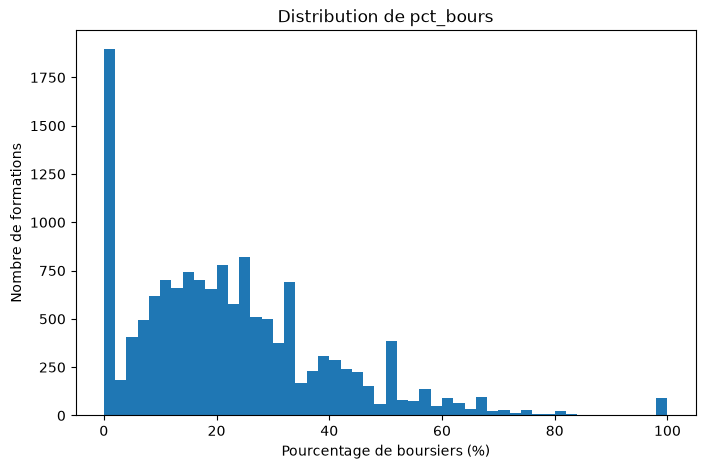

C:\Users\mathi\AppData\Local\Temp\ipykernel_6152\2956744203.py:30: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df["pct_bours"].dropna(), vert=False)


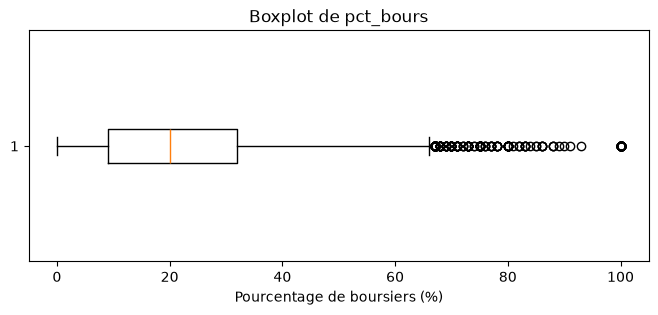

IQR : bornes [-25.5 ; 66.5] -> 338 outliers (2.4%)
Z-score : seuil |z| > 3 -> 149 outliers (1.0%)


In [46]:
# print(df["pct_bours"].describe())
print("Type :", df["pct_bours"].dtype)
print("Minimum :", df["pct_bours"].min())
print("Maximum :", df["pct_bours"].max())

moyenne = df["pct_bours"].mean()
mediane = df["pct_bours"].median()
print("Moyenne :", moyenne)
print("Médiane :", mediane)

ecart_type = df["pct_bours"].std()
Q1 = df["pct_bours"].quantile(0.25)
Q3 = df["pct_bours"].quantile(0.75)
IQR = Q3 - Q1
CV = ecart_type / moyenne
print("Écart-type :", ecart_type)
print("Q1 :", Q1)
print("Q3 :", Q3)
print("IQR :", IQR)
print("Coefficient de variation :", CV)

plt.figure(figsize=(8, 5))
plt.hist(df["pct_bours"].dropna(), bins=50)
plt.xlabel("Pourcentage de boursiers (%)")
plt.ylabel("Nombre de formations")
plt.title("Distribution de pct_bours")
plt.show()

plt.figure(figsize=(8, 3))
plt.boxplot(df["pct_bours"].dropna(), vert=False)
plt.xlabel("Pourcentage de boursiers (%)")
plt.title("Boxplot de pct_bours")
plt.show()

var = ["pct_bours"]
objectif = pd.DataFrame({
    "skewness": df[var].skew(),
    "kurtosis": df[var].kurt()
})
objectif

capa = df["pct_bours"]

q1, q3 = capa.quantile([0.25, 0.75])
iqr = q3 - q1
borne_inf = q1 - 1.5 * iqr
borne_sup = q3 + 1.5 * iqr
outliers_iqr = capa[(capa < borne_inf) | (capa > borne_sup)]

z = (capa - capa.mean()) / capa.std()
outliers_z = capa[z.abs() > 3]

print(f"IQR : bornes [{borne_inf:.1f} ; {borne_sup:.1f}] -> {len(outliers_iqr)} outliers ({len(outliers_iqr)/len(capa):.1%})")
print(f"Z-score : seuil |z| > 3 -> {len(outliers_z)} outliers ({len(outliers_z)/len(capa):.1%})")

**Analyse** : _à rédiger_

### Variable qualitative : `region_etab_aff`

18 modalités
['Auvergne-Rhône-Alpes', 'Bourgogne-Franche-Comté', 'Bretagne', 'Centre', 'Corse', 'Grand-Est', 'Guadeloupe', 'Guyane', 'Hauts-de-France', 'Ile-de-France', 'Martinique', 'Mayotte', 'Normandie', 'Nouvelle Aquitaine', 'Occitanie', 'Pays-de-la-Loire', "Provence-Alpes-Côte d'Azur", 'Réunion']
Valeurs manquantes : 97
Mode : Ile-de-France
Part de la modalité dominante : 19.0%


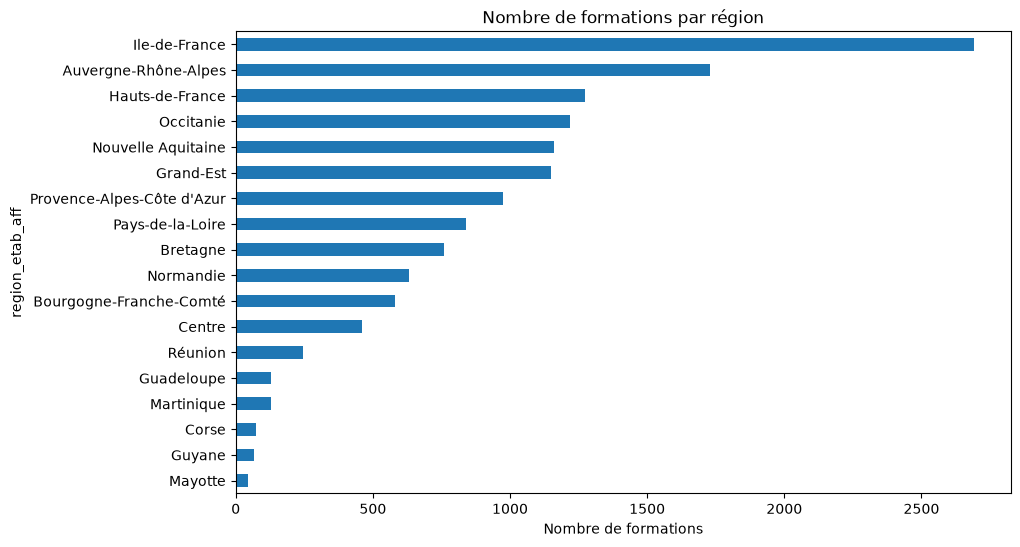

region_etab_aff
Ile-de-France                 19.0
Auvergne-Rhône-Alpes          12.2
Hauts-de-France                9.0
Occitanie                      8.6
Nouvelle Aquitaine             8.2
Grand-Est                      8.1
Provence-Alpes-Côte d'Azur     6.9
Pays-de-la-Loire               5.9
Bretagne                       5.4
Normandie                      4.5
Bourgogne-Franche-Comté        4.1
Centre                         3.3
Réunion                        1.7
Guadeloupe                     0.9
Martinique                     0.9
Corse                          0.5
Guyane                         0.5
Mayotte                        0.3
Name: proportion, dtype: float64


In [276]:
region = df["region_etab_aff"]

print(region.nunique(), "modalités")
print(sorted(region.dropna().unique()))

print("Valeurs manquantes :", region.isna().sum())

effectifs = region.value_counts()
print("Mode :", effectifs.index[0])
print(f"Part de la modalité dominante : {effectifs.iloc[0] / effectifs.sum():.1%}")

plt.figure(figsize=(10, 6))
effectifs.sort_values().plot(kind="barh")
plt.title("Nombre de formations par région")
plt.xlabel("Nombre de formations")
plt.show()

print((region.value_counts(normalize=True) * 100).round(1))

**Analyse** : region_etab_aff est une variable nominale à 18 modalités, avec 97 valeurs manquantes
La répartition est très concentrée en Île-de-France et Auverge Rhone-Alpes

> 💾 **Commit** : « Analyse univariée », puis **push**.

## 📝 Synthèse J1 — Ce qu'on sait sur la sélectivité

- À quoi ressemble la sélectivité d'une formation typique ? Les formations sont-elles proches ou très différentes ?
- Quels premiers indices avez-vous trouvés sur ce qui la fait varier ?
- Quelles variables faudra-t-il transformer pour la suite, et pourquoi ?

4 à 6 lignes.

**Synthèse** : _à rédiger_

> 💾 **Commit** : « Synthèse J1 », puis **push**.

# J2 matin — Mettre en pratique les fondements mathématiques de la corrélation

## 10. Covariance

🎯 *Enquête* : on passe au bivarié. On apprend d'abord à mesurer un lien sur un couple simple (capacité × vœux), avant de l'appliquer à la sélectivité.

**10.1** Tracez le nuage de points de `voe_tot` en fonction de `capa_fin`. Calculez leur covariance à la main (produits des écarts), puis avec pandas.

**Interprétation** : _à rédiger_

**10.2** Recalculez la covariance avec la capacité exprimée en centaines de places. Que constatez-vous ?

**Interprétation** : _à rédiger_

> 💾 **Commit** : « Covariance »

## 11. Corrélation de Pearson

🎯 *Enquête* : première mesure chiffrée du lien entre la demande et la sélectivité.

**11.1** Calculez r entre `capa_fin` et `voe_tot` à la main (covariance / produit des écarts-types), puis avec pandas. Faites de même pour `voe_tot` et `taux_acces_ens`. Que dit ce second coefficient sur la sélectivité ?

**Interprétation** : _à rédiger_

**11.2** Les conditions de Pearson sont-elles respectées ? Recalculez r entre `log(capa_fin)` et `log(voe_tot)` (en excluant les valeurs nulles).

**Interprétation** : _à rédiger_

> 💾 **Commit** : « Pearson »

## 12. Corrélation de Spearman

🎯 *Enquête* : le lien demande × sélectivité est-il sous-estimé par Pearson ?

**12.1** Calculez Spearman pour les deux couples de la question 11.1. Comparez avec Pearson et expliquez les écarts.

**Interprétation** : _à rédiger_

> 💾 **Commit** : « Spearman »

## 13. Tests d'hypothèse

🎯 *Enquête* : le lien entre demande et sélectivité est-il réel, ou dû au hasard ? Et quel coefficient retenir pour la suite ?

**13.1** Testez la normalité de `taux_acces_ens` avec Shapiro-Wilk et Anderson-Darling, sur un échantillon de 50 formations puis sur toutes. Formulez H0 et concluez. Quel coefficient de corrélation retiendrez-vous pour la suite de l'enquête ?

**Interprétation** : _à rédiger_

**13.2** Testez la corrélation entre `voe_tot` et `taux_acces_ens` (Spearman). Formulez H0, donnez la p-value et concluez. Le lien est-il fort pour autant ?

**Interprétation** : _à rédiger_

> 💾 **Commit** : « Tests », puis **push**.

# J2 après-midi — Approfondir les relations quantitatives

## 14. Corrélation partielle

🎯 *Enquête* : le lien entre demande et sélectivité tient-il à capacité égale ?

**14.1** Calculez la corrélation entre `log(voe_tot)` et `taux_acces_ens`, puis la corrélation partielle en contrôlant `log(capa_fin)`. Que concluez-vous ?

**Interprétation** : _à rédiger_

> 💾 **Commit** : « Corrélation partielle »

## 15. A/B testing

🎯 *Enquête* : un lien observé suffit-il à affirmer qu'un facteur *cause* la sélectivité ?

**15.1** Au J3, vous verrez que les formations privées ont un taux d'accès plus élevé que les publiques. Peut-on en conclure que le statut privé *rend* une formation moins sélective ? Quelle expérience faudrait-il pour le prouver, et est-elle possible ici ?

**Interprétation** : _à rédiger_

**15.2** Reprenez la simulation de la démo avec 500 visiteurs, puis 20 000. Une version B qui fait passer le taux d'achat de 20 % à 22 %. L'effet est-il détecté dans les deux cas ? Pourquoi ?

**Interprétation** : _à rédiger_

> 💾 **Commit** : « A/B testing »

## 16. Matrice de corrélation

🎯 *Enquête* : vue d'ensemble. Quelles variables quantitatives sont liées à la sélectivité, et lesquelles disent la même chose ?

**16.1** Tracez la heatmap des corrélations de Spearman entre `capa_fin`, `voe_tot`, `acc_tot`, `taux_acces_ens`, `pct_bours`, `pct_f`, `pct_tb`. Quelles variables sont redondantes ? Quelles variables sont les meilleures candidates pour expliquer la sélectivité ?

**Interprétation** : _à rédiger_

## 17. Régression simple

🎯 *Enquête* : le niveau scolaire des admis explique-t-il la sélectivité, et dans quelle mesure ?

**17.1** Régressez `taux_acces_ens` sur `pct_tb` (part de mentions très bien parmi les admis). Donnez la pente, le R², et tracez les résidus. Les mentions TB expliquent-elles la sélectivité ?

**Interprétation** : _à rédiger_

> 💾 **Commit** : « Régression », puis **push**.

## 📝 Synthèse J2 — Ce qu'on sait sur la sélectivité

- Quelles variables quantitatives sont liées à la sélectivité, avec quelle force ?
- Le lien avec la demande tient-il quand on contrôle la taille ?
- Peut-on parler de causes ? Pourquoi ?

4 à 6 lignes.

**Synthèse** : _à rédiger_

> 💾 **Commit** : « Synthèse J2 », puis **push**.

# J3 matin — Comprendre les fondements du bivarié qualitatif

## 18. Table de contingence et Chi²

🎯 *Enquête* : le label « formation sélective » dépend-il du statut de l'établissement ?

**18.1** Croisez `select_form` et `contrat_etab` : table des effectifs, puis fréquences conditionnelles par statut.

**Interprétation** : _à rédiger_

**18.2** Faites le test du Chi² d'indépendance (H0, effectifs théoriques, p-value), puis calculez le V de Cramér et les résidus standardisés.

**Interprétation** : _à rédiger_

> 💾 **Commit** : « Chi² »

## 19. Quantitatif × qualitatif

🎯 *Enquête* : la sélectivité varie-t-elle selon le statut (public / privé) et selon la filière ?

**19.1** Le `taux_acces_ens` diffère-t-il entre formations publiques et privées ? Boxplot, Student (Welch) et Mann-Whitney.

**Interprétation** : _à rédiger_

**19.2** Le `taux_acces_ens` diffère-t-il selon la filière (`fili`) ? ANOVA et Kruskal-Wallis. Quelles filières sont les plus sélectives ?

**Interprétation** : _à rédiger_

> 💾 **Commit** : « Quanti × quali », puis **push**.

# J3 après-midi — Introduire le multivarié

## 20. ACP

🎯 *Enquête* : on rassemble toutes les variables. Où se place la sélectivité parmi elles ?

**20.1** Faites une ACP sur `log(capa_fin)`, `log(voe_tot)`, `taux_acces_ens`, `pct_bours`, `pct_f`, `pct_tb` (centrées-réduites). Quelle part de variance portent les deux premiers axes ? Interprétez-les à partir des contributions. Où se place `taux_acces_ens` sur ces axes ?

**Interprétation** : _à rédiger_

> 💾 **Commit** : « ACP », puis **push**.

## 🏁 Conclusion de l'enquête

Répondez à la question : **qu'est-ce qui rend une formation sélective sur Parcoursup ?**

- Les facteurs retenus, classés par importance, chacun appuyé par un chiffre du TP.
- Les pistes écartées.
- Les limites : ce que vos analyses ne permettent pas d'affirmer.

10 à 15 lignes. Cette conclusion compte dans la note du TP.

**Synthèse** : _à rédiger_

> 💾 **Commit** : « Conclusion de l'enquête », puis **push**.